In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")
folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
print("NAV")
print(nav.columns)

print("\nAUM")
print(aum.columns)

print("\nSIP")
print(sip.columns)

print("\nCATEGORY")
print(category.columns)

print("\nTRANSACTIONS")
print(transactions.columns)

print("\nFOLIO")
print(folio.columns)

print("\nPORTFOLIO")
print(portfolio.columns)

NAV
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

CATEGORY
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

FOLIO
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

PORTFOLIO
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [4]:
# NAV Trend Analysis

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All 40 Schemes (2022–2026)"
)

fig.show()

Insight:
Most mutual fund schemes showed a steady upward NAV trend between 2022 and 2026, reflecting long-term growth in fund performance.

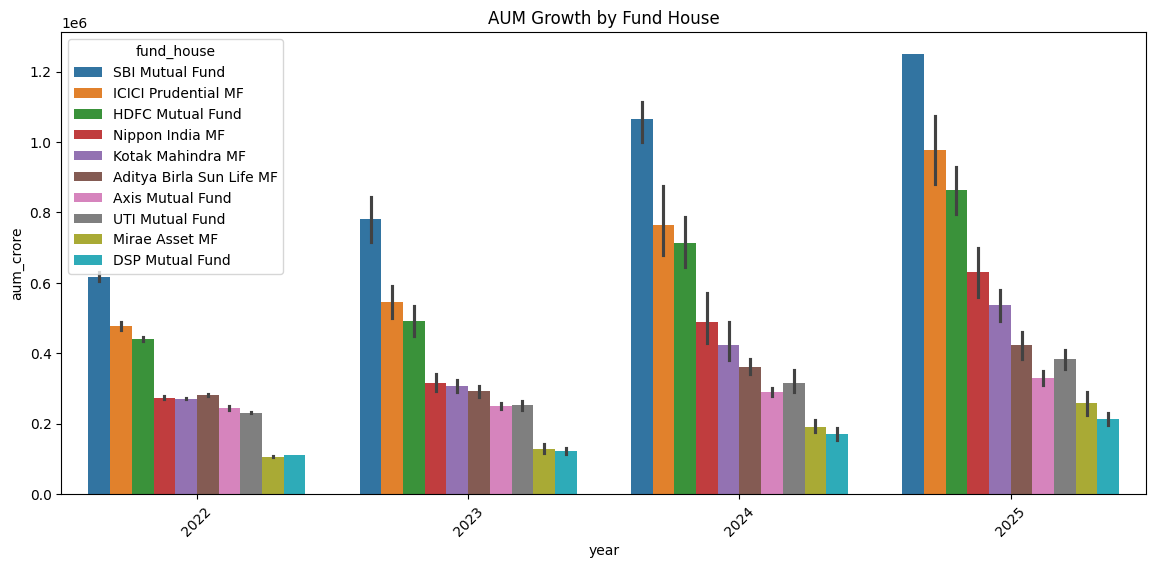

In [5]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.show()

Insight:
AUM is concentrated among a few large fund houses, with SBI maintaining industry leadership.

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

Insight :
SIP inflows increased steadily from 2022 to 2025, reaching record levels by the end of 2025.

In [7]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


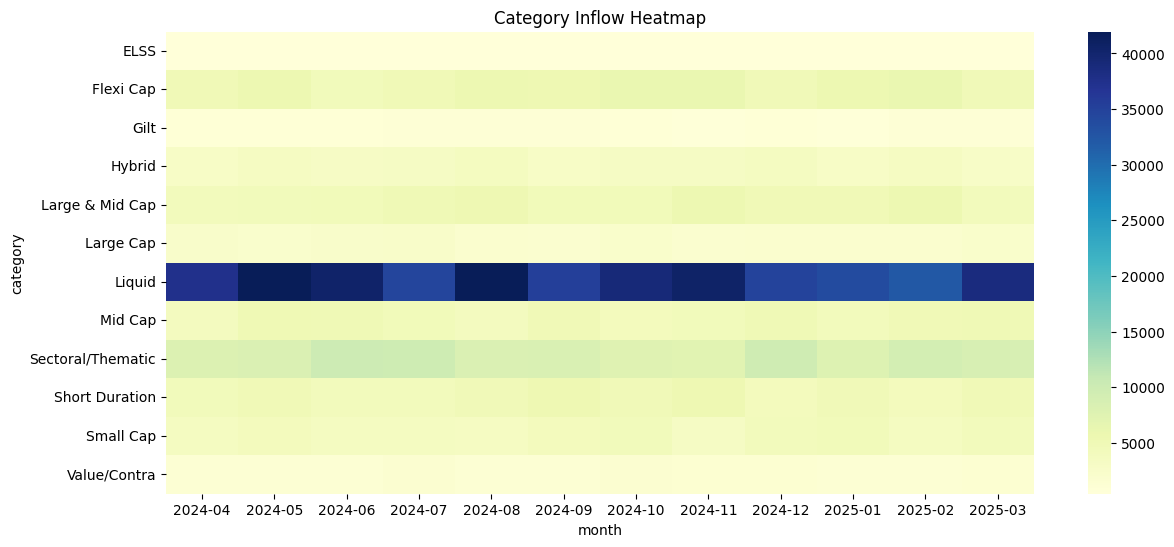

In [8]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

Insight:
Equity-oriented categories attracted higher net inflows compared to debt categories during most months.

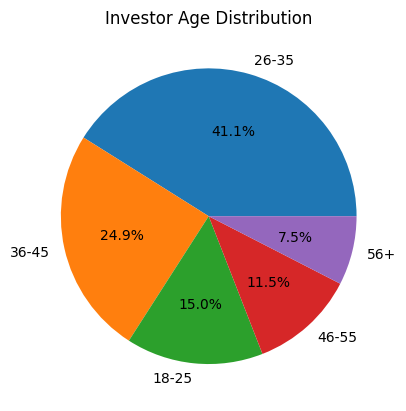

In [9]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")
plt.ylabel("")
plt.show()

Insight:
Investors aged 26–35 form the largest investor segment, accounting for 41.1% of total investors, indicating strong mutual fund participation among young professionals.

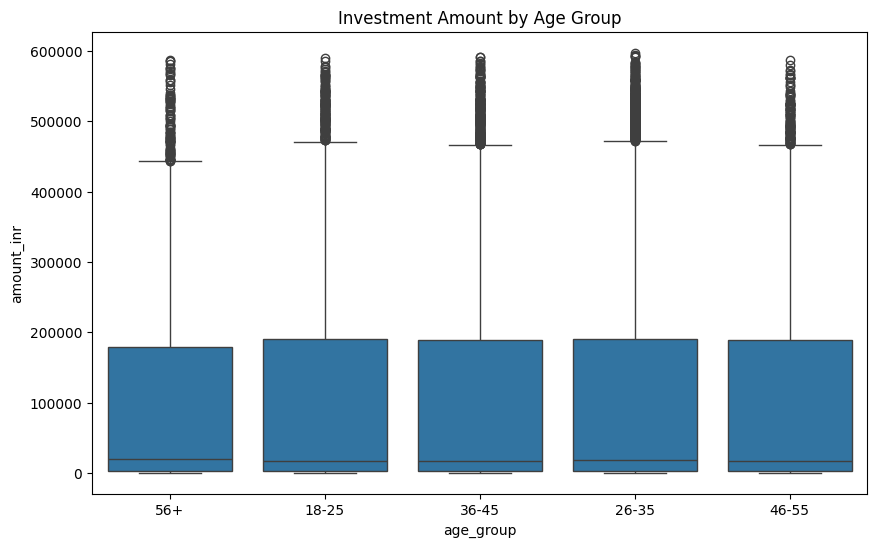

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

Insight :
Investment amounts vary significantly across all age groups, with several high-value investors (outliers) contributing investments above ₹4 lakh, indicating the presence of both retail and high-net-worth investors.

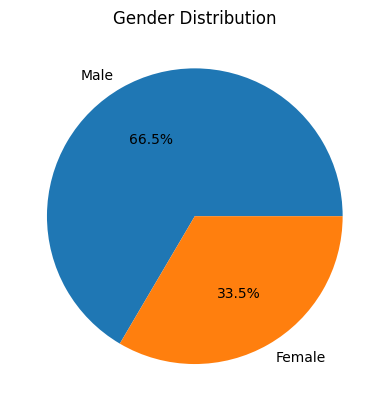

In [11]:
transactions["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Insight:
Male investors account for 66.5% of the investor base, while female investors represent 33.5%, indicating a significant gender gap in mutual fund participation.

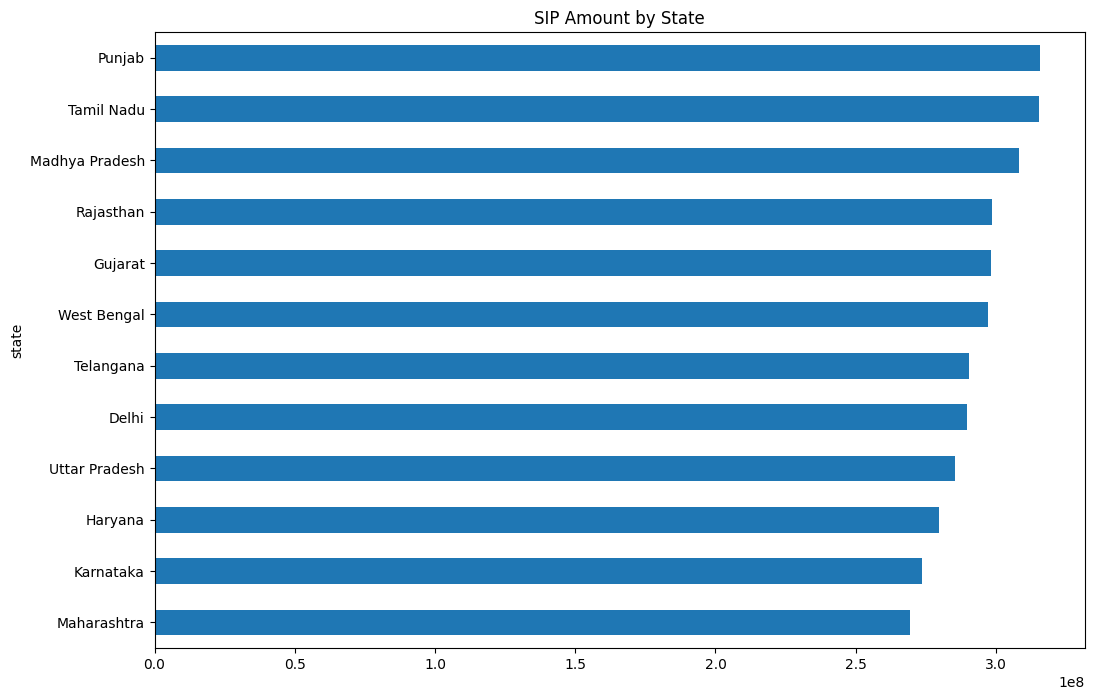

In [12]:
state_amount = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_amount.plot.barh()

plt.title("SIP Amount by State")
plt.show()

Insight:
Punjab recorded the highest total SIP investment amount, followed closely by Tamil Nadu and Madhya Pradesh, while Maharashtra contributed comparatively lower SIP investments among the selected states.


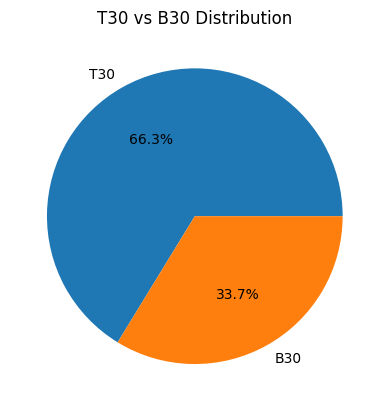

In [13]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")
plt.show()

Insight:
T30 cities account for 66.3% of investors, while B30 cities contribute 33.7%, indicating that mutual fund participation remains concentrated in major urban centers.

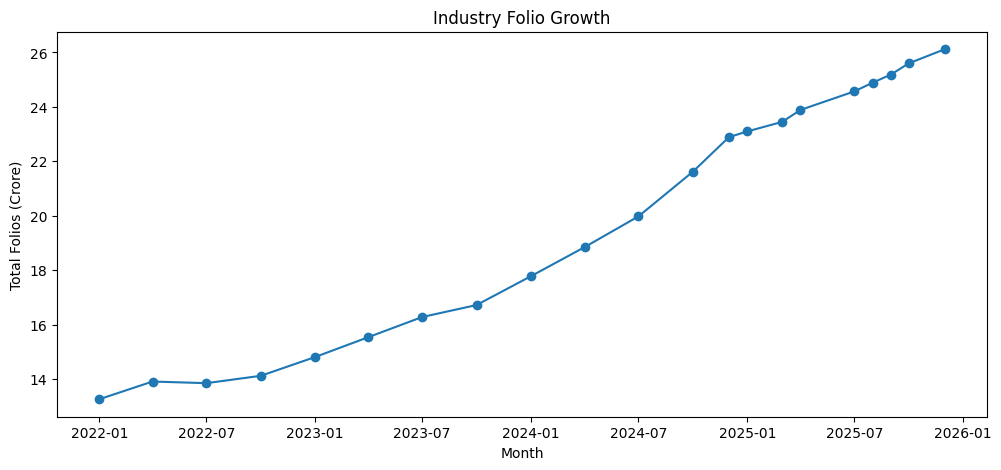

In [14]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.show()

Insight:
Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore by December 2025, reflecting strong growth in investor participation across the industry.

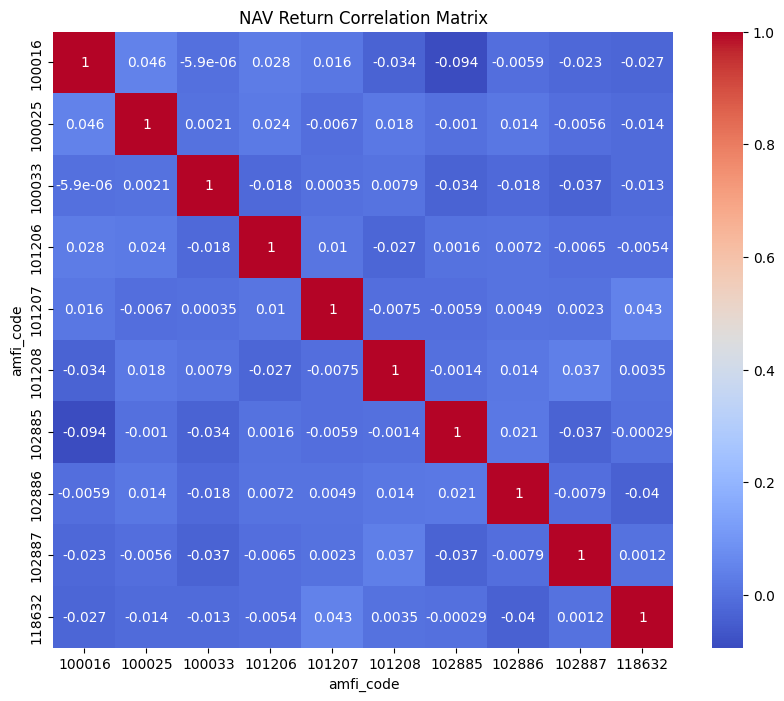

In [15]:
nav["nav"] = pd.to_numeric(nav["nav"])

selected_codes = nav["amfi_code"].unique()[:10]

corr_data = nav[
    nav["amfi_code"].isin(selected_codes)
]

returns = (
    corr_data
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
    .pct_change()
)

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

Insight:
The selected mutual funds exhibit very low return correlations, with most correlation values close to zero, indicating diversification benefits and limited co-movement among fund returns.

In [16]:
sector_alloc = (
    portfolio.groupby("sector")
    ["weight_pct"]
    .sum()
)

fig = px.pie(
    values=sector_alloc.values,
    names=sector_alloc.index,
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

Insight:
Banking is the largest sector allocation at 19.2%, followed by IT (13.4%) and Pharma (12.0%), indicating that equity mutual funds are heavily concentrated in financial services and technology sectors.

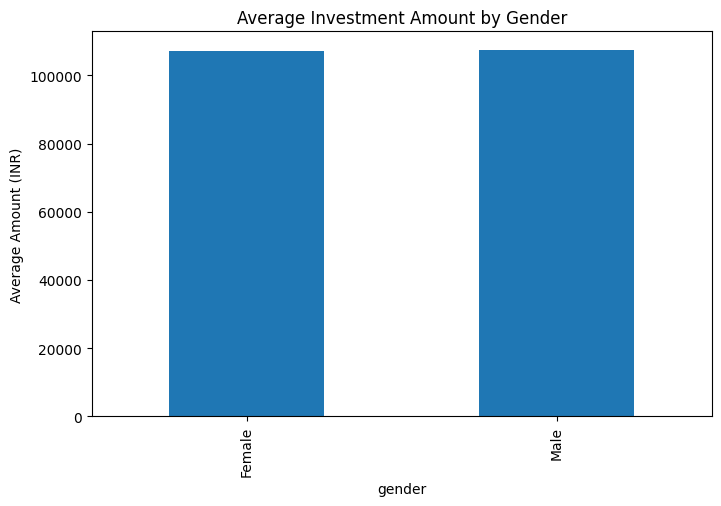

In [17]:
plt.figure(figsize=(8,5))

transactions.groupby("gender")["amount_inr"].mean().plot(
    kind="bar"
)

plt.title("Average Investment Amount by Gender")
plt.ylabel("Average Amount (INR)")
plt.show()

insight: 
Male investors contribute a higher average investment amount compared to female investors.

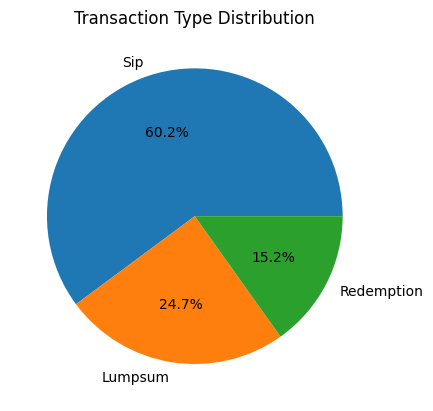

In [18]:
transactions["transaction_type"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.ylabel("")
plt.show()

insight: 
SIP transactions account for the largest share of investor activity, highlighting the popularity of systematic investing.

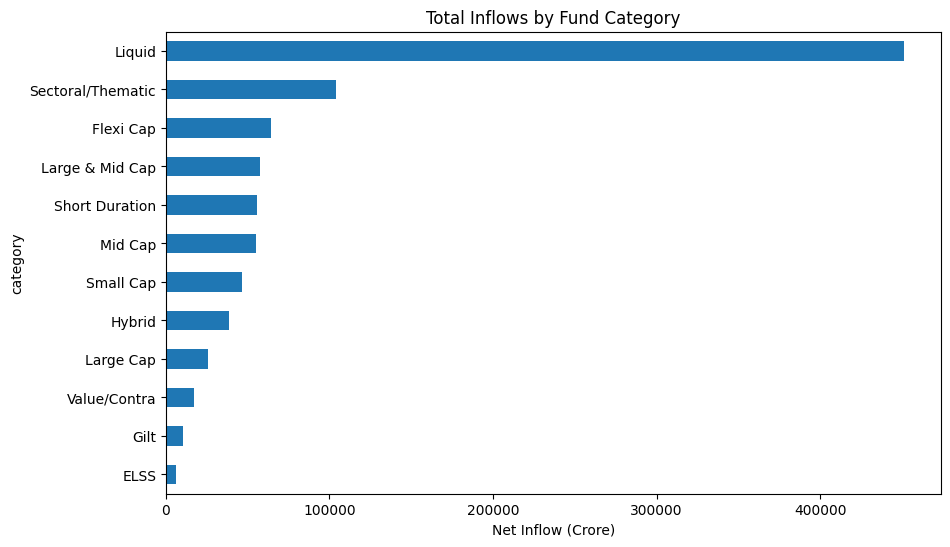

In [19]:
category.groupby("category")["net_inflow_crore"].sum().sort_values().plot.barh(
    figsize=(10,6)
)

plt.title("Total Inflows by Fund Category")
plt.xlabel("Net Inflow (Crore)")
plt.show()

insight : 
Certain fund categories attract significantly higher inflows, reflecting investor preference for specific investment themes.